In [10]:
import argparse
import json
import os
import tempfile
import numpy as np
import subprocess
from tqdm import tqdm
import pandas as pd
import datetime
import time
import gc
import random
import sys
import shutil
import glob

sys.path.append('/home/agustin/phd/synthesis')
sys.path.append('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils')




# mine
import utils.nifti_functions as nfc
import utils.util as util
import utils.functions as fc
import utils.util_freesurfer_segmentation as ufs
import utils.gpu_selector as gpu_selector
import data_loaders.load_dataset as load_dataset
import utils.data_normalization as data_normalization

import prep_image as prep_image


from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# images
from PIL import Image
import matplotlib.pyplot as plt
sys.path.append('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils')

# Do not limit the number of columns
pd.set_option('display.max_columns', None)

### Global histogram matching

In [ ]:
import numpy as np


def compute_reference_quantiles(
    images,
    masks=None,
    quantiles=np.linspace(0, 100, 1001),
    lower_clip=0,
    upper_clip=100,
):
    """
    Compute a mean reference distribution from a dataset.

    Parameters
    ----------
    images : list[np.ndarray]
    masks : list[np.ndarray]
    quantiles : np.ndarray
    lower_clip : float
    upper_clip : float

    Returns
    -------
    reference_quantiles : np.ndarray
    """

    all_quantiles = []

    if masks is None:
        masks = [np.ones_like(img, dtype=bool) for img in images]

    for img, mask in zip(images, masks):

        voxels = img[mask > 0]

        if len(voxels) == 0:
            continue

        low = np.percentile(voxels, lower_clip)
        high = np.percentile(voxels, upper_clip)

        voxels = voxels[
            (voxels >= low) &
            (voxels <= high)
        ]

        q = np.percentile(voxels, quantiles)
        all_quantiles.append(q)

    reference_quantiles = np.mean(
        np.stack(all_quantiles, axis=0),
        axis=0
    )

    return reference_quantiles


def match_histogram_quantiles(
    image,
    reference_quantiles,
    mask=None,
    quantiles=np.linspace(0, 100, 1001),
):
    """
    Match image intensities to a reference distribution.

    Parameters
    ----------
    image : np.ndarray
    mask : np.ndarray
    reference_quantiles : np.ndarray

    Returns
    -------
    matched_image : np.ndarray
    """

    if mask is None:
        mask = np.ones_like(image, dtype=bool)

    matched = image.copy()

    voxels = image[mask > 0]

    source_quantiles = np.percentile(
        voxels,
        quantiles
    )

    matched[mask > 0] = np.interp(
        voxels,
        source_quantiles,
        reference_quantiles
    )

    return matched




### Per tissue histrogram matching

In [12]:
def compute_reference_quantiles_tissuewise(
    images,
    segs,
    quantiles=np.linspace(0, 100, 101),
    lower_clip=1,
    upper_clip=99,
    tissues = {
    "csf": 1,
    "gm": 2,
    "wm": 3,
    }
):
    """
    Compute reference landmarks for each tissue.
    """

    reference = {}

    for tissue, labels in tissues.items():

        all_subject_quantiles = []

        for img, seg in zip(images, segs):

            mask = np.isin(seg, labels)

            voxels = img[mask]

            if len(voxels) < 100:
                continue

            low = np.percentile(voxels, lower_clip)
            high = np.percentile(voxels, upper_clip)

            voxels = voxels[
                (voxels >= low) &
                (voxels <= high)
            ]

            all_subject_quantiles.append(
                np.percentile(voxels, quantiles)
            )

        reference[tissue] = np.mean(
            np.stack(all_subject_quantiles),
            axis=0
        )

    return reference

def build_global_landmark_mapping(
    image,
    seg,
    reference_quantiles,
    quantiles=np.linspace(0, 100, 101),
    tissues = {
    "csf": 1,
    "gm": 2,
    "wm": 3,
    }
):
    """
    Compute source->target landmarks using
    WM, GM and CSF simultaneously.
    """

    src_landmarks = []
    tgt_landmarks = []

    for tissue, labels in tissues.items():

        mask = np.isin(seg, labels)

        voxels = image[mask]

        if len(voxels) < 100:
            continue

        src_q = np.percentile(
            voxels,
            quantiles
        )

        tgt_q = reference_quantiles[tissue]

        src_landmarks.append(src_q)
        tgt_landmarks.append(tgt_q)

    src_landmarks = np.concatenate(src_landmarks)
    tgt_landmarks = np.concatenate(tgt_landmarks)

    idx = np.argsort(src_landmarks)

    src_landmarks = src_landmarks[idx]
    tgt_landmarks = tgt_landmarks[idx]

    src_landmarks, unique_idx = np.unique(
        src_landmarks,
        return_index=True
    )

    tgt_landmarks = tgt_landmarks[unique_idx]

    return src_landmarks, tgt_landmarks

def match_histogram_quantiles_tissuewise(
    image,
    seg,
    reference_quantiles,
    brain_mask=None,
    quantiles=np.linspace(0, 100, 101),
):
    """
    Tissue-aware Nyul-style normalization.

    Computes tissue-specific landmarks but
    applies ONE smooth mapping to the image.
    """

    if brain_mask is None:
        brain_mask = seg > 0

    matched = image.copy()

    src_landmarks, tgt_landmarks = (
        build_global_landmark_mapping(
            image,
            seg,
            reference_quantiles,
            quantiles,
        )
    )

    matched[brain_mask] = np.interp(
        image[brain_mask],
        src_landmarks,
        tgt_landmarks,
    )

    return matched


### Load histogram

In [13]:

def load_mean_histogram( modalities=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1, 1.5, 3, 5, 7], max_images=4, per_tissue=False):
    # max_images = 4
   
    # resolutions = [0.1, 1.5]
    # resolutions = [0.1, 1.5, 3, 5, 7]

    training_df =  pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv")
    training_df = training_df[training_df["split"] == "train"]

    # results = {}
    mean_histograms = {}
    
    for modality in modalities:
        # results[modality] = {}
        mean_histograms[modality] = {}

        for resolution in resolutions:
            # results[modality][resolution] = []
            mean_histograms[modality][resolution] = []

            possible_rows = training_df[(training_df["modality"] == modality) & (training_df["resolution"] == resolution)]
            
            available = min(len(possible_rows), max_images)
            if available == 0:
                print(f"No images available for modality {modality} and resolution {resolution}")
                continue
            selected_rows = possible_rows.sample(n=available, random_state=42)
            # load images
            
            _selected_images = []
            _selected_segs = []
            _selected_masks = []
            bar = tqdm(total=available, desc=f"Loading images for modality {modality} and resolution {resolution}")
            for i, row in selected_rows.iterrows():
                img_path = row["org_img_path"]
                img = nfc.load_nifti(img_path)[0]
                seg = nfc.load_nifti(row["seg_synthseg_path"])[0]

                if per_tissue:
                    seg = ufs.merge_seg96_to_seg3(seg)

                # normalize image to 0-1
                img = util.robust_normalize(img, strictly_positive=True, mask=seg > 0)
                # results[modality][resolution].append(img) 
                _selected_images.append(img)  
                _selected_masks.append(seg > 0)
                _selected_segs.append(seg)
                bar.update(1)
            bar.close()
            # mean_histograms[modality][resolution] = compute_mean_histogram(_selected_images, n_percentiles=1000)[1]
            if not per_tissue:
                mean_histograms[modality][resolution] = compute_reference_quantiles(_selected_images, masks=_selected_masks, quantiles=np.linspace(0, 100, 1001))
            else:
                mean_histograms[modality][resolution] = compute_reference_quantiles_tissuewise(_selected_images, _selected_segs, quantiles=np.linspace(0, 100, 101))
    return mean_histograms


In [14]:
# mean_histograms_global = load_mean_histogram(modalities=["T1W"], resolutions=[7], max_images=10, per_tissue=False)


In [15]:
# mean_histograms_pertissue = load_mean_histogram(modalities=["T1W"], resolutions=[7], max_images=2, per_tissue=True)


In [ ]:
output_dir = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/postprocessing/histogram_matching/mean_histograms"

mean_histograms_global = {}
for modality in ["T1W", "T2W", "T2FLAIR"]:
    mean_histograms_global[modality] = {}
    for resolution in [0.1, 1.5, 3, 5, 7]:
        mean_histograms_global[modality][resolution] = np.load(os.path.join(output_dir, f"{modality}_{resolution}.npy"))

In [17]:
org_img_a, _ = nfc.load_nifti('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/zip/training/unzip/release_20260414/Training_prospective/T1W/3T/P_T1W_3T_0006.nii.gz')
org_img_b, _ = nfc.load_nifti('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/zip/training/unzip/release_20260414/Training_prospective/T1W/7T/P_T1W_7T_0007.nii.gz')

org_seg_a, _ = nfc.load_nifti('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/train_data/preprocessed/synthseg/T1W/3.0T/SP_T1W_3T_0006_synthseg_resampled.nii.gz')
org_seg_b, _ = nfc.load_nifti('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/train_data/preprocessed/synthseg/T1W/7.0T/SP_T1W_7T_0007_synthseg_resampled.nii.gz')


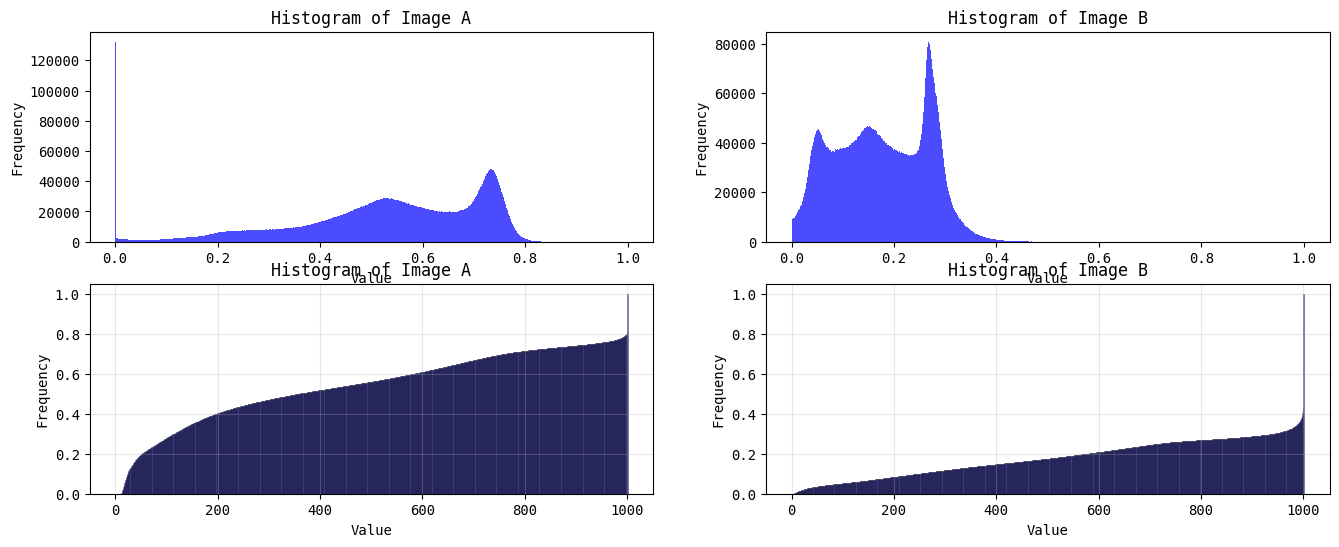

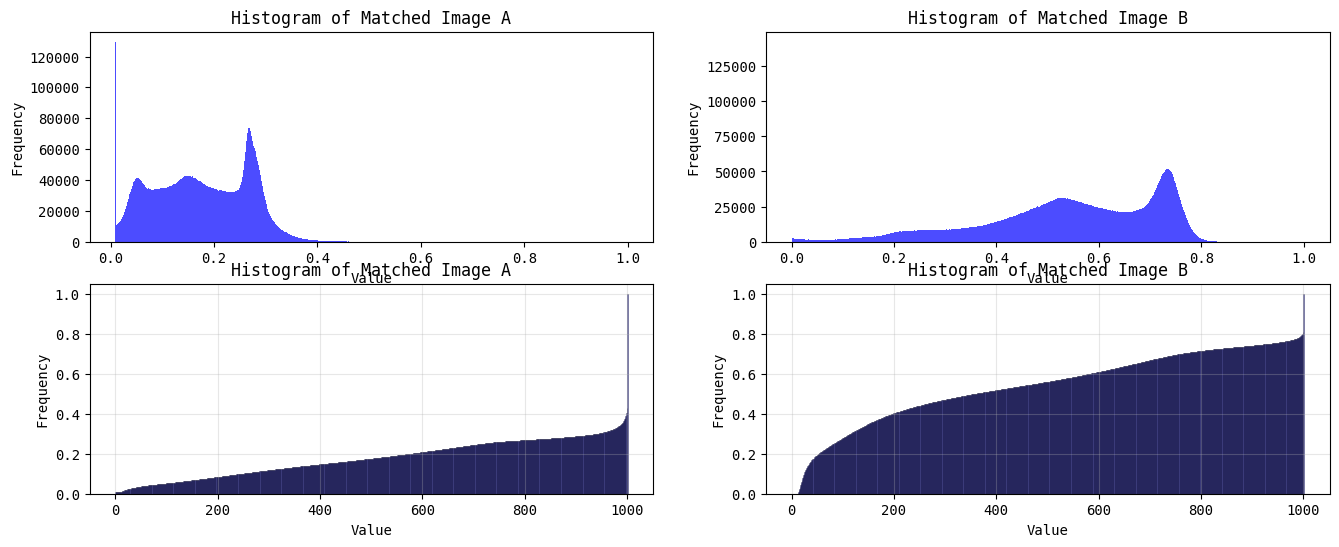

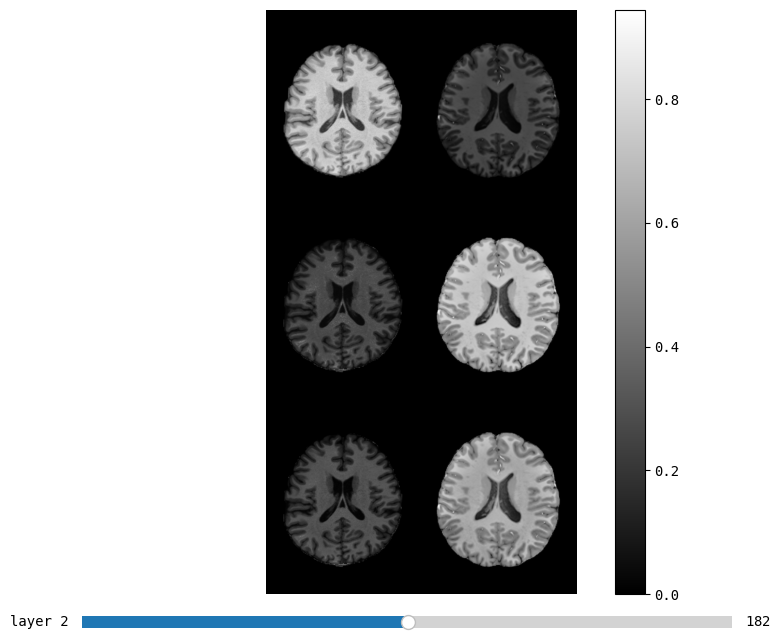

In [21]:
img_a, img_b = org_img_a.copy(), org_img_b.copy()
seg_a, seg_b = org_seg_a.copy(), org_seg_b.copy()

img_a = util.robust_normalize(img_a, mask=seg_a > 0)
img_b = util.robust_normalize(img_b, mask=seg_b > 0)
# fc.imgshow_3D_list([img_a, img_b])

reference_quantiles_a = compute_reference_quantiles([img_a], masks=[seg_a > 0]) 
reference_quantiles_b = compute_reference_quantiles([img_b], masks=[seg_b > 0]) 


fig, ax = plt.subplots(2, 2, figsize=(16, 6))
fc.plot_hist(img_a[seg_a > 0], bins=1000, title="Histogram of Image A", ax=ax[0][0])
fc.plot_hist(img_b[seg_b > 0], bins=1000, title="Histogram of Image B", ax=ax[0][1])
fc.plot_precomputed_hist(reference_quantiles_a, bins=1000, title="Histogram of Image A", ax=ax[1][0])
fc.plot_precomputed_hist(reference_quantiles_b, bins=1000, title="Histogram of Image B", ax=ax[1][1])



# match histogram of image A to reference quantiles of image B

matched_a = match_histogram_quantiles(img_a, reference_quantiles_b, mask=seg_a > 0)
matched_b = match_histogram_quantiles(img_b, reference_quantiles_a, mask=seg_b > 0)

matched_reference_quantiles_a = compute_reference_quantiles([matched_a], masks=[seg_a > 0]) 
matched_reference_quantiles_b = compute_reference_quantiles([matched_b], masks=[seg_b > 0]) 

matched_a_mean = match_histogram_quantiles(img_a, mean_histograms_global["T1W"][7], mask=seg_a > 0)
matched_b_mean = match_histogram_quantiles(img_b, mean_histograms_global["T1W"][0.1], mask=seg_b > 0)
# matched_a_mean_pertissue = match_histogram_quantiles_tissuewise(img_a, ufs.merge_seg96_to_seg3(seg_a), mean_histograms_pertissue["T1W"][7], brain_mask=seg_a > 0)

fig, ax = plt.subplots(2, 2, figsize=(16, 6))
fc.plot_hist(matched_a[seg_a > 0], bins=1000, title="Histogram of Matched Image A", ax=ax[0][0])
fc.plot_hist(matched_b[seg_b > 0], bins=1000, title="Histogram of Matched Image B", ax=ax[0][1])
fc.plot_precomputed_hist(matched_reference_quantiles_a, bins=1000, title="Histogram of Matched Image A", ax=ax[1][0])
fc.plot_precomputed_hist(matched_reference_quantiles_b, bins=1000, title="Histogram of Matched Image B", ax=ax[1][1])

custom_disposition = (None,2)
fc.imgshow_3D_list([img_a, img_b, 
                    matched_a, matched_b, 
                    matched_a_mean, matched_b_mean], custom_disposition=custom_disposition)
# fc.imgshow_3D_list([img_a, img_b, matched_a, matched_b, matched_a_mean, matched_a_mean_pertissue])
